In [ ]:
#VGG16 Model

In [1]:
import sys
print(sys.version)

3.8.2 (default, May  6 2020, 09:02:42) [MSC v.1916 64 bit (AMD64)]


Total images found: 7055
Found 5644 validated image filenames belonging to 14 classes.
Found 1411 validated image filenames belonging to 14 classes.


C:\Users\siris\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1188s 26s/step - accuracy: 0.4022 - loss: 2.5287 - val_accuracy: 0.8682 - val_loss: 0.4812
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1667s 37s/step - accuracy: 0.9156 - loss: 0.3496 - val_accuracy: 0.9327 - val_loss: 0.2890
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1989s 45s/step - accuracy: 0.9667 - loss: 0.1811 - val_accuracy: 0.9532 - val_loss: 0.2003
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 999s 22s/step - accuracy: 0.9835 - loss: 0.1103 - val_accuracy: 0.9589 - val_loss: 0.1690
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 891s 20s/step - accuracy: 0.9921 - loss: 0.0774 - val_accuracy: 0.9554 - val_loss: 0.1596
Training Accuracy: 99.40%
Validation Accuracy: 95.54%


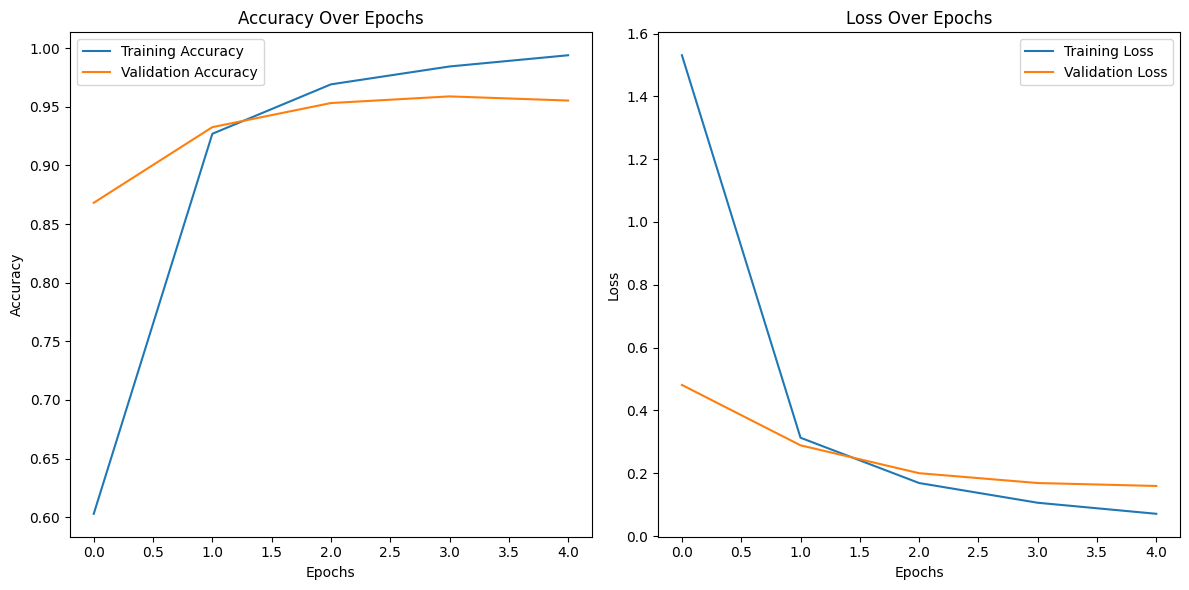

Model saved to vgg16_plant_disease_model.h5


In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

# Step 1: Set the dataset directory
DATASET_DIR = r"C:\Users\siris\OneDrive\Desktop\archive\dataset"

# Step 2: List all files in the dataset directory recursively to inspect
all_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        all_files.append(os.path.join(root, file))

# Step 3: Check for image files with various extensions (account for uppercase extensions)
valid_extensions = ('.jpg', '.png', '.jpeg', '.bmp', '.gif', 
                    '.JPG', '.PNG', '.JPEG', '.BMP', '.GIF')

# List all image files in the directory
all_images = [f for f in all_files if f.lower().endswith(valid_extensions)]

# Step 4: Ensure images are found
if len(all_images) == 0:
    raise ValueError("No image files found in the dataset directory! Check the path and file extensions.")
else:
    print(f"Total images found: {len(all_images)}")

# Step 5: Create a DataFrame with filenames and labels
df = pd.DataFrame({"filename": all_images})
df["label"] = df["filename"].apply(lambda x: os.path.basename(os.path.dirname(x)))  # Extract the label from folder name

# Step 6: Split into train and validation sets (80-20 split)
train_df, valid_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# Step 7: Image preprocessing
train_datagen = ImageDataGenerator(rescale=1.0/255)
valid_datagen = ImageDataGenerator(rescale=1.0/255)

batch_size = 128

# Step 8: Load training data
training_set = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATASET_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="categorical"
)

# Step 9: Load validation data
valid_set = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=DATASET_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="categorical"
)

#  Step 10: Define the VGG16 model with custom classifier
num_classes = len(training_set.class_indices)  # Get number of classes from the training set

# Load VGG16 pre-trained model without the top layer (top=False means we remove fully connected layers)
base_model = VGG16(include_top=False, input_shape=(224, 224, 3))

# Freeze the VGG16 layers so they are not trained
base_model.trainable = False

# Build the custom model with VGG16 as a feature extractor
classifier = models.Sequential([
    base_model,  # Adding the pre-trained VGG16 model
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # Output layer for multi-class classification
])

# Step 11: Compile the model
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 12: Fit the model
history = classifier.fit(
    training_set,
    steps_per_epoch=len(training_set) // batch_size,  # Calculate steps_per_epoch
    validation_data=valid_set,
    epochs=5,
    validation_steps=len(valid_set) // batch_size  # Calculate validation_steps
)

# Step 13: Print the accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

print(f" VGG16 Training Accuracy: {train_accuracy[-1]*100:.2f}%")
print(f" VGG16 Validation Accuracy: {val_accuracy[-1]*100:.2f}%")

# Step 14: Plot accuracy and loss graphs (optional)
plt.figure(figsize=(12, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#VGG19 model

Total images found: 7055
Found 5644 validated image filenames belonging to 14 classes.
Found 1411 validated image filenames belonging to 14 classes.


C:\Users\siris\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1095s 24s/step - accuracy: 0.3217 - loss: 3.2328 - val_accuracy: 0.8150 - val_loss: 0.7026
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1233s 28s/step - accuracy: 0.8772 - loss: 0.5181 - val_accuracy: 0.9022 - val_loss: 0.3971
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1140s 26s/step - accuracy: 0.9424 - loss: 0.2887 - val_accuracy: 0.9178 - val_loss: 0.3097
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1114s 25s/step - accuracy: 0.9607 - loss: 0.1941 - val_accuracy: 0.9369 - val_loss: 0.2389
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1194s 27s/step - accuracy: 0.9766 - loss: 0.1320 - val_accuracy: 0.9391 - val_loss: 0.2139
 VGG19 Training Accuracy: 97.93%
 VGG19 Validation Accuracy: 93.91%


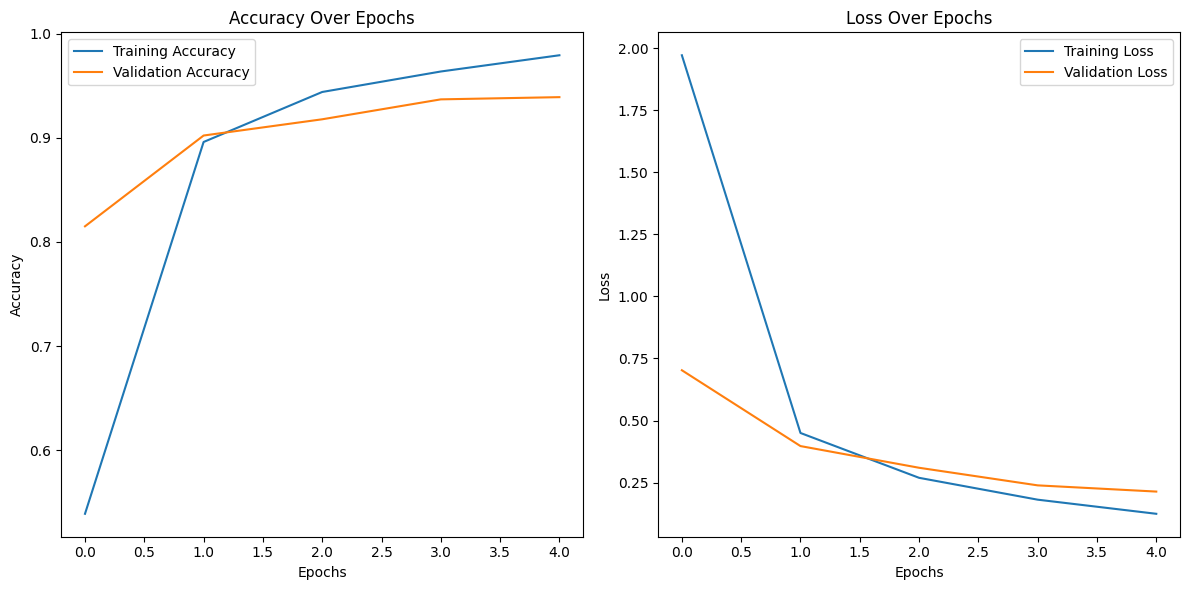

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19  # Import VGG19 instead of VGG16
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

# Step 1: Set the dataset directory
DATASET_DIR = r"C:\Users\siris\OneDrive\Desktop\archive\dataset"

# Step 2: List all files in the dataset directory recursively to inspect
all_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        all_files.append(os.path.join(root, file))

# Step 3: Check for image files with various extensions (account for uppercase extensions)
valid_extensions = ('.jpg', '.png', '.jpeg', '.bmp', '.gif', 
                    '.JPG', '.PNG', '.JPEG', '.BMP', '.GIF')

# List all image files in the directory
all_images = [f for f in all_files if f.lower().endswith(valid_extensions)]

#  Step 4: Ensure images are found
if len(all_images) == 0:
    raise ValueError("No image files found in the dataset directory! Check the path and file extensions.")
else:
    print(f"Total images found: {len(all_images)}")

# Step 5: Create a DataFrame with filenames and labels
df = pd.DataFrame({"filename": all_images})
df["label"] = df["filename"].apply(lambda x: os.path.basename(os.path.dirname(x)))  # Extract the label from folder name

# Step 6: Split into train and validation sets (80-20 split)
train_df, valid_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# Step 7: Image preprocessing
train_datagen = ImageDataGenerator(rescale=1.0/255)
valid_datagen = ImageDataGenerator(rescale=1.0/255)

batch_size = 128

# Step 8: Load training data
training_set = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATASET_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="categorical"
)

# Step 9: Load validation data
valid_set = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=DATASET_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="categorical"
)

#  Step 10: Define the VGG19 model with custom classifier
num_classes = len(training_set.class_indices)  # Get number of classes from the training set

# Load VGG19 pre-trained model without the top layer (include_top=False means we remove fully connected layers)
base_model = VGG19(include_top=False, input_shape=(224, 224, 3))

# Freeze the VGG19 layers so they are not trained
base_model.trainable = False

# Build the custom model with VGG19 as a feature extractor
classifier = models.Sequential([
    base_model,  # Adding the pre-trained VGG19 model
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # Output layer for multi-class classification
])

# Step 11: Compile the model
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 12: Fit the model
history = classifier.fit(
    training_set,
    steps_per_epoch=len(training_set) // batch_size,  # Calculate steps_per_epoch
    validation_data=valid_set,
    epochs=5,
    validation_steps=len(valid_set) // batch_size  # Calculate validation_steps
)

# Step 13: Print the accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

print(f" VGG19 Training Accuracy: {train_accuracy[-1]*100:.2f}%")
print(f" VGG19 Validation Accuracy: {val_accuracy[-1]*100:.2f}%")

# Step 14: Plot accuracy and loss graphs (optional)
plt.figure(figsize=(12, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
# RESNET101V2 Model

Total images found: 7055
Found 5644 validated image filenames belonging to 14 classes.
Found 1411 validated image filenames belonging to 14 classes.


C:\Users\siris\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 554s 12s/step - accuracy: 0.4950 - loss: 1.6349 - val_accuracy: 0.9114 - val_loss: 0.2928
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 496s 11s/step - accuracy: 0.8926 - loss: 0.3368 - val_accuracy: 0.9398 - val_loss: 0.1937
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 505s 11s/step - accuracy: 0.9233 - loss: 0.2487 - val_accuracy: 0.9546 - val_loss: 0.1569
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 512s 11s/step - accuracy: 0.9504 - loss: 0.1542 - val_accuracy: 0.9589 - val_loss: 0.1306
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 629s 14s/step - accuracy: 0.9667 - loss: 0.1186 - val_accuracy: 0.9561 - val_loss: 0.1309
 ResNet101V2 Training Accuracy: 96.42%
 ResNet101V2 Validation Accuracy: 95.61%


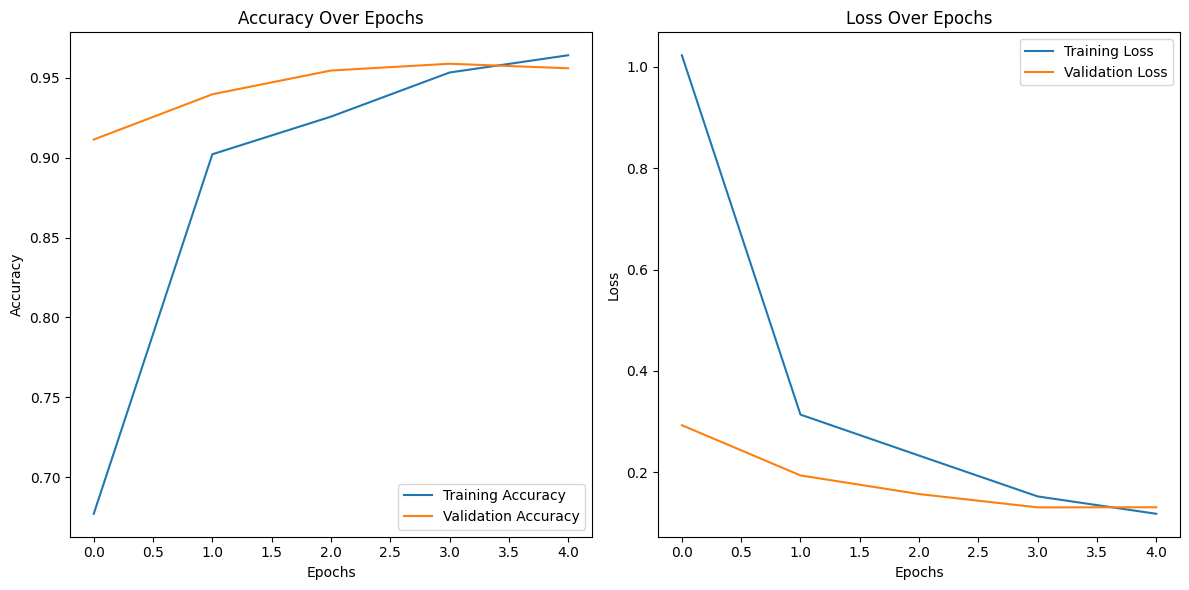

In [5]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet101V2  # Import ResNet101V2
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

# Step 1: Set the dataset directory
DATASET_DIR = r"C:\Users\siris\OneDrive\Desktop\archive\dataset"

# Step 2: List all files in the dataset directory recursively to inspect
all_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        all_files.append(os.path.join(root, file))

# Step 3: Check for image files with various extensions (account for uppercase extensions)
valid_extensions = ('.jpg', '.png', '.jpeg', '.bmp', '.gif', 
                    '.JPG', '.PNG', '.JPEG', '.BMP', '.GIF')

# List all image files in the directory
all_images = [f for f in all_files if f.lower().endswith(valid_extensions)]

#  Step 4: Ensure images are found
if len(all_images) == 0:
    raise ValueError("No image files found in the dataset directory! Check the path and file extensions.")
else:
    print(f"Total images found: {len(all_images)}")

# Step 5: Create a DataFrame with filenames and labels
df = pd.DataFrame({"filename": all_images})
df["label"] = df["filename"].apply(lambda x: os.path.basename(os.path.dirname(x)))  # Extract the label from folder name

# Step 6: Split into train and validation sets (80-20 split)
train_df, valid_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# Step 7: Image preprocessing
train_datagen = ImageDataGenerator(rescale=1.0/255)
valid_datagen = ImageDataGenerator(rescale=1.0/255)

batch_size = 128

# Step 8: Load training data
training_set = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATASET_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="categorical"
)

# Step 9: Load validation data
valid_set = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=DATASET_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="categorical"
)

# Step 10: Define the ResNet101V2 model with a custom classifier
num_classes = len(training_set.class_indices)  # Get number of classes from the training set

# Load ResNet101V2 pre-trained model without the top layer (include_top=False)
base_model = ResNet101V2(include_top=False, input_shape=(224, 224, 3))

# Freeze the ResNet101V2 layers so they are not trained
base_model.trainable = False

# Build the custom model with ResNet101V2 as a feature extractor
classifier = models.Sequential([
    base_model,  # Adding the pre-trained ResNet101V2 model
    layers.GlobalAveragePooling2D(),  # Global Average Pooling instead of Flatten
    layers.Dense(256, activation='relu'),  #  Increased neurons to 256
    layers.Dropout(0.5),  # Dropout to reduce overfitting
    layers.Dense(num_classes, activation='softmax')  # Output layer for multi-class classification
])

# Step 11: Compile the model
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 12: Fit the model
history = classifier.fit(
    training_set,
    steps_per_epoch=len(training_set) // batch_size,  # Calculate steps_per_epoch
    validation_data=valid_set,
    epochs=5,
    validation_steps=len(valid_set) // batch_size  # Calculate validation_steps
)

# Step 13: Print the accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

print(f" ResNet101V2 Training Accuracy: {train_accuracy[-1]*100:.2f}%")
print(f" ResNet101V2 Validation Accuracy: {val_accuracy[-1]*100:.2f}%")

# Step 14: Plot accuracy and loss graphs (optional)
plt.figure(figsize=(12, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
#InceptionV3 Model 

Total images found: 7055
Found 5644 validated image filenames belonging to 14 classes.
Found 1411 validated image filenames belonging to 14 classes.


C:\Users\siris\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 92s 92s/step - accuracy: 0.0469 - loss: 2.9425 - val_accuracy: 0.1099 - val_loss: 2.7859
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 77s 77s/step - accuracy: 0.0781 - loss: 2.8789 - val_accuracy: 0.2601 - val_loss: 2.5020
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 80s 80s/step - accuracy: 0.2500 - loss: 2.5745 - val_accuracy: 0.2736 - val_loss: 2.3721
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 79s 79s/step - accuracy: 0.1562 - loss: 2.6388 - val_accuracy: 0.2778 - val_loss: 2.2422
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 83s 83s/step - accuracy: 0.1875 - loss: 2.4490 - val_accuracy: 0.4026 - val_loss: 2.0792
InceptionV3 Training Accuracy: 18.75%
InceptionV3 Validation Accuracy: 40.26%


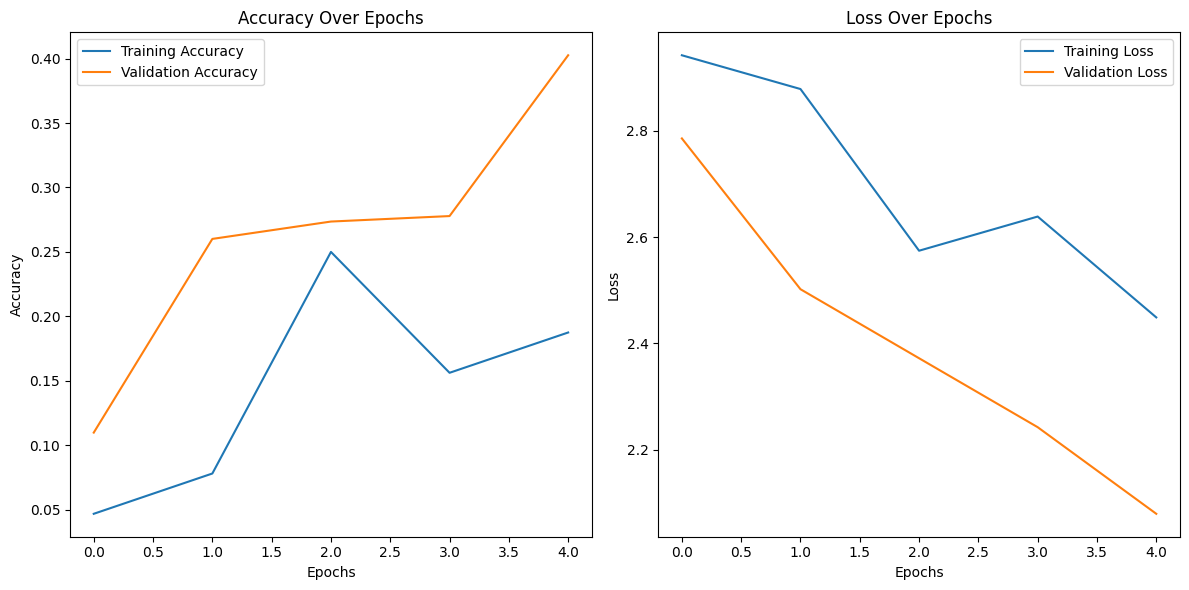

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3  # Import InceptionV3
import matplotlib.pyplot as plt

# Step 1: Set the dataset directory
DATASET_DIR = r"C:\Users\siris\OneDrive\Desktop\archive\dataset"

#  Step 2: List all files in the dataset directory recursively
all_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        all_files.append(os.path.join(root, file))

# Step 3: Filter valid image files (case-insensitive extensions)
valid_extensions = ('.jpg', '.png', '.jpeg', '.bmp', '.gif', '.JPG', '.PNG', '.JPEG', '.BMP', '.GIF')
all_images = [f for f in all_files if f.lower().endswith(valid_extensions)]

# Step 4: Ensure images are found
if len(all_images) == 0:
    raise ValueError("No image files found in the dataset directory! Check the path and file extensions.")
else:
    print(f"Total images found: {len(all_images)}")

# Step 5: Create a DataFrame with filenames and labels
df = pd.DataFrame({"filename": all_images})
df["label"] = df["filename"].apply(lambda x: os.path.basename(os.path.dirname(x)))  # Extract label from folder name

# Step 6: Split into train and validation sets (80-20 split)
train_df, valid_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# Step 7: Image preprocessing
train_datagen = ImageDataGenerator(rescale=1.0/255)
valid_datagen = ImageDataGenerator(rescale=1.0/255)

batch_size = 64  # Reduced batch size for better memory efficiency

# Step 8: Load training data
training_set = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="label",
    target_size=(299, 299),  # Updated for InceptionV3
    batch_size=batch_size,
    class_mode="categorical"
)

# Step 9: Load validation data
valid_set = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="filename",
    y_col="label",
    target_size=(299, 299),  # Updated for InceptionV3
    batch_size=batch_size,
    class_mode="categorical"
)

# Step 10: Define the InceptionV3 model
num_classes = len(training_set.class_indices)  # Get number of classes

# Load InceptionV3 without the top layer
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze the base model

# Build the classifier
classifier = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Use GAP instead of Flatten
    layers.Dense(256, activation='relu'),  # Increased neurons for better learning
    layers.Dropout(0.5),  # Dropout to reduce overfitting
    layers.Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])

# Step 11: Compile the model
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#  Step 12: Train the model
history = classifier.fit(
    training_set,
    steps_per_epoch=len(training_set) // batch_size,
    validation_data=valid_set,
    epochs=5,
    validation_steps=len(valid_set) // batch_size
)

# Step 13: Print final accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

print(f"InceptionV3 Training Accuracy: {train_accuracy[-1]*100:.2f}%")
print(f"InceptionV3 Validation Accuracy: {val_accuracy[-1]*100:.2f}%")

# Step 14: Plot accuracy and loss graphs
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#Ensemble model

In [73]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import layers, models

# Constants
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 5
DATASET_DIR = r"C:\Users\siris\OneDrive\Desktop\archive\dataset"  # Your dataset directory

# Load dataset and prepare DataFrame
def create_image_dataframe(dataset_dir):
    image_paths = []
    labels = []
    class_names = os.listdir(dataset_dir)
    
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(dataset_dir, class_name)
        if os.path.isdir(class_folder):
            for image_file in os.listdir(class_folder):
                if image_file.lower().endswith(('png', 'jpg', 'jpeg')):
                    image_paths.append(os.path.join(class_folder, image_file))
                    labels.append(label)
                    
    df = pd.DataFrame({
        'image_path': image_paths,
        'label': labels
    })
    
    return df

# Create DataFrame for all images
df = create_image_dataframe(DATASET_DIR)

# Image generator function
def image_generator(df, batch_size):
    while True:
        df = df.sample(frac=1).reset_index(drop=True)  # Shuffle data
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start:start + batch_size]
            images = []
            labels = []
            for _, row in batch.iterrows():
                img_path = row['image_path']
                img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
                img = img_to_array(img) / 255.0  # Normalize image
                images.append(img)
                labels.append(row['label'])
            
            images = np.array(images)
            labels = np.array(labels)

            # Pad the batch if it's smaller than BATCH_SIZE
            if len(images) < batch_size:
                # Pad images with zero arrays and labels with a zero label
                padding = batch_size - len(images)
                images = np.pad(images, ((0, padding), (0, 0), (0, 0), (0, 0)), mode='constant')
                labels = np.pad(labels, (0, padding), mode='constant')
            
            yield images, labels

# Prepare the dataset
dataset = tf.data.Dataset.from_generator(
    lambda: image_generator(df, BATCH_SIZE),
    output_signature=(
        tf.TensorSpec(shape=(BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32),  # Input images
        tf.TensorSpec(shape=(BATCH_SIZE,), dtype=tf.int32)  # Labels
    )
)

# Define base models
def create_base_model(model_type):
    if model_type == 'VGG16':
        return tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    elif model_type == 'VGG19':
        return tf.keras.applications.VGG19(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    elif model_type == 'InceptionV3':
        return tf.keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    elif model_type == 'ResNet50':
        return tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Define the ensemble model
def create_ensemble_model():
    model_input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    # Create the individual models
    vgg16_base = create_base_model('VGG16')
    vgg19_base = create_base_model('VGG19')
    inceptionv3_base = create_base_model('InceptionV3')
    resnet50_base = create_base_model('ResNet50')
    
    # Freeze the base models
    vgg16_base.trainable = False
    vgg19_base.trainable = False
    inceptionv3_base.trainable = False
    resnet50_base.trainable = False

    # Pass the inputs through each model
    x1 = vgg16_base(model_input)
    x1 = layers.GlobalAveragePooling2D()(x1)
    
    x2 = vgg19_base(model_input)
    x2 = layers.GlobalAveragePooling2D()(x2)
    
    x3 = inceptionv3_base(model_input)
    x3 = layers.GlobalAveragePooling2D()(x3)
    
    x4 = resnet50_base(model_input)
    x4 = layers.GlobalAveragePooling2D()(x4)

    # Combine the outputs (concatenate or average them)
    combined = layers.concatenate([x1, x2, x3, x4])

    # Add custom layers on top
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(len(os.listdir(DATASET_DIR)), activation='softmax')(x)  # Multi-class output

    ensemble_model = models.Model(model_input, output)
    ensemble_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return ensemble_model

# Create the ensemble model
ensemble_model = create_ensemble_model()

# Train the model
history = ensemble_model.fit(
    dataset,
    epochs=EPOCHS,
    steps_per_epoch=len(df) // BATCH_SIZE
)

# Print final training accuracy
final_train_acc = history.history['accuracy'][-1] * 100
print(f"Final Training Accuracy: {final_train_acc:.2f}%")


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 3009s 14s/step - accuracy: 0.6240 - loss: 1.2159
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 3103s 14s/step - accuracy: 0.9222 - loss: 0.2427
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 2387s 11s/step - accuracy: 0.9582 - loss: 0.1192
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 2391s 11s/step - accuracy: 0.9652 - loss: 0.0974
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 2254s 10s/step - accuracy: 0.9828 - loss: 0.0542
Final Training Accuracy: 98.12%


In [ ]:
#SAVING ENSEMBLE MODEL

In [75]:
SAVE_PATH = r'G:/My Drive/PLANT_LEAF_DISEASE_PREDICTION/ensemble_model.h5'

# Save the ensemble model
ensemble_model.save(SAVE_PATH)

print(f"Model saved successfully at {SAVE_PATH}")


Model saved successfully at G:/My Drive/PLANT_LEAF_DISEASE_PREDICTION/ensemble_model.h5


In [ ]:
# CUSTOM INPUT and OUTPUT

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

# Load the trained model
MODEL_PATH = r'ensemble_model.h5'
ensemble_model = load_model(MODEL_PATH)
print("Model loaded successfully!")
ensemble_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Image preprocessing function
def preprocess_image(image_path):
    IMG_HEIGHT, IMG_WIDTH = 224, 224
    if not os.path.exists(image_path):
        print(f"ERROR: Image not found at {image_path}")
        return None
    img = load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img = img_to_array(img) / 255.0  # Normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Test image path (replace with your image path)
TEST_IMAGE_PATH = r'dataset\Apple___Apple_scab\0a6812de-7416-4ffe-aba9-307599a02c84___FREC_Scab 2973_new30degFlipLR.JPG'

# Make prediction
image = preprocess_image(TEST_IMAGE_PATH)
if image is not None:
    prediction = ensemble_model.predict(image)
    predicted_class_index = np.argmax(prediction)

    # Load class names
    DATASET_DIR = r"dataset"

    # Ensure dataset path exists
    if not os.path.exists(DATASET_DIR):
        print(f"ERROR: Dataset directory not found at {DATASET_DIR}")
        exit()

    # Load class names from the dataset directory
    class_names = sorted(os.listdir(DATASET_DIR))

    # Check if any subdirectories are found (representing classes)
    if len(class_names) == 0:
        print(f"ERROR: No class directories found in {DATASET_DIR}")
        exit()

    # Get the predicted class name
    predicted_class = class_names[predicted_class_index]

    # Display the prediction
    print(f"Predicted Leaf Disease: {predicted_class}")


✅ Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
🟢 Predicted Leaf Disease: Apple___Apple_scab


In [15]:
import shutil
shutil.copy("PLANT_LEAF_DISEASE.ipynb", "G:/My Drive/PLANT_LEAF_DISEASE_PREDICTION")

'G:/My Drive/PLANT_LEAF_DISEASE_PREDICTION\\PLANT_LEAF_DISEASE.ipynb'

In [3]:
import sys
print(sys.version)

3.8.2 (default, May  6 2020, 09:02:42) [MSC v.1916 64 bit (AMD64)]
